# Lab Assignment
## Name: Tasrif Nur Himel

### ID: 221-35-1078
### Course: DS422	- Machine Learning Driven Data Analysis Lab I (DS Major)
### Section: B1

## Library install and Import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import matplotlib
#matplotlib.rcParams['figure.figsize'] = (20,10)

In [2]:
!pip -q install missingno

In [2]:
import missingno as msno

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

import warnings, re
warnings.filterwarnings("ignore")
np.random.seed(42)


In [3]:
df = pd.read_csv("/content/bengaluru_house_prices.csv")
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


## Sanity checks

In [4]:
df.groupby('area_type')['area_type'].agg('count')

,area_type
area_type,
Built-up Area,2418
Carpet Area,87
Plot Area,2025
Super built-up Area,8790


### Make Copy

In [5]:
base_df = df.copy()
base_df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


### Missing Summary Visualize

In [6]:
missing = base_df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(base_df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df


,missing_count,missing_pct
society,5502,41.31
balcony,609,4.57
bath,73,0.55
size,16,0.12
location,1,0.01
area_type,0,0.00
availability,0,0.00
total_sqft,0,0.00
price,0,0.00


### Visualize missingness (matrix + correlations)

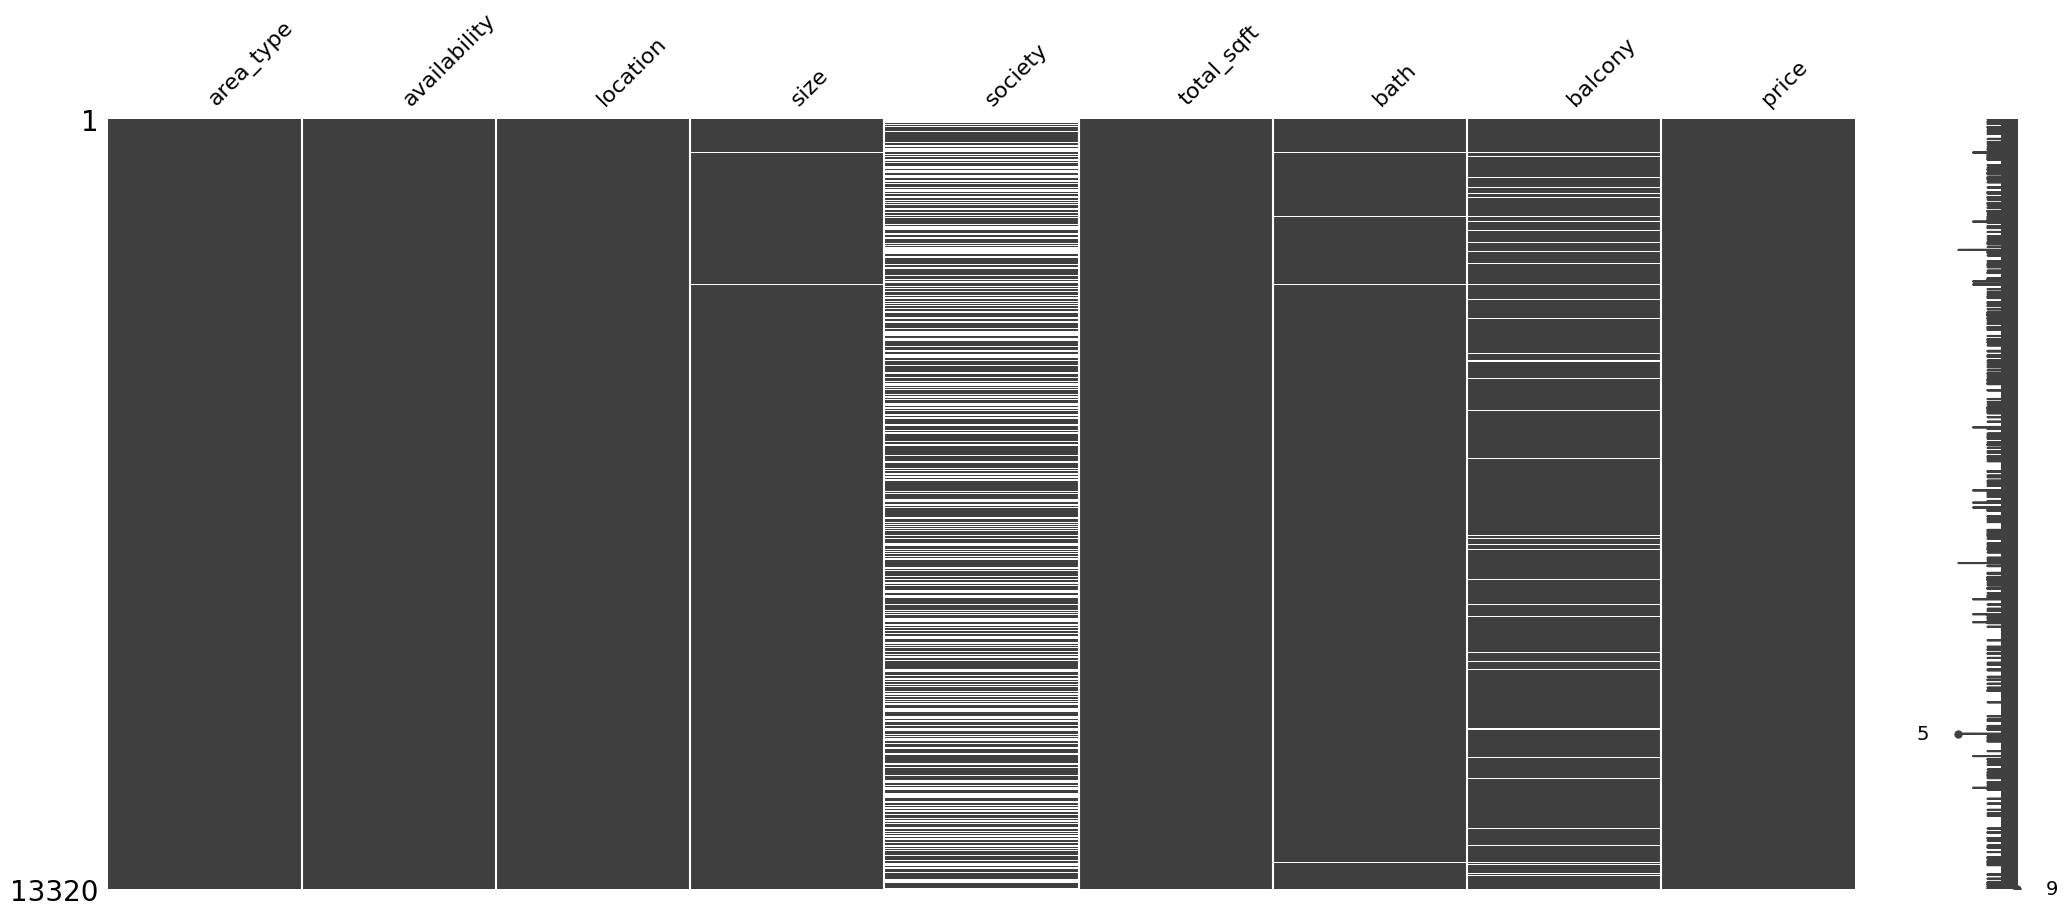

In [7]:
msno.matrix(base_df)
plt.show()

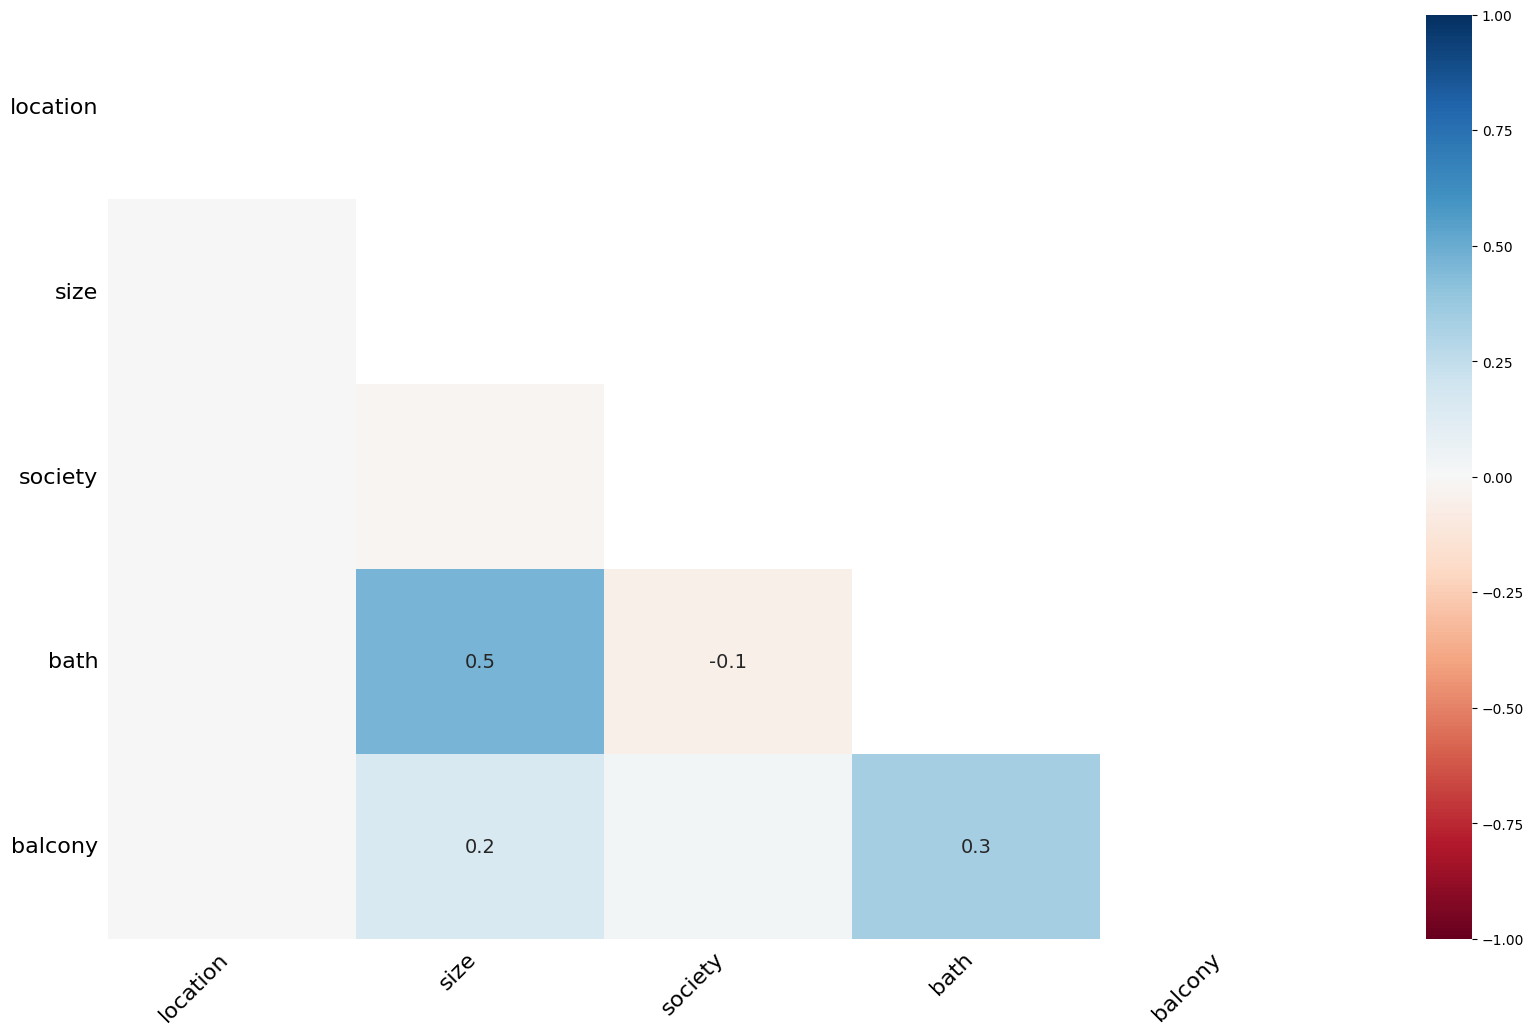

In [8]:
msno.heatmap(base_df)
plt.show()

heavy missingness in society, moderate in balcony, tiny in bath/size, almost none elsewhere.

the missingness heatmap shows only weak correlation between missing fields → we'll treat columns mostly independently (but we’ll still try grouped ffill/bfill within location later).

before we set up the imputation variants + models, let’s lock in consistent numeric features so our comparisons are fair. specifically:

parse total_sqft to a clean numeric value in square feet (handle ranges like 1200-1500 and unit strings like Sq. Meter, Acres, etc.).

derive bhk from size (e.g., “2 BHK”, “3 Bedroom” → 2/3).

### Feature engineering: clean total_sqft and derive bhk

In [9]:

import re

work_df = base_df.copy()

UNIT_TO_SQFT = {
    "sqft": 1.0,
    "sq. ft": 1.0,
    "square feet": 1.0,
    "ft2": 1.0,
    "sqft.": 1.0,
    "sqftft": 1.0,

    "sq. meter": 10.7639,
    "sq meter": 10.7639,
    "sqm": 10.7639,
    "m2": 10.7639,

    "sq. yard": 9.0,
    "sq yard": 9.0,
    "sq. yards": 9.0,
    "sq yards": 9.0,
    "yd2": 9.0,
    "gaj": 9.0,

    "acre": 43560.0,
    "acres": 43560.0,
    "hectare": 107639.104,

    "ground": 2400.0,
    "grounds": 2400.0,

    "cent": 435.6,
    "cents": 435.6,

    "guntha": 1089.0,
    "gunta": 1089.0,
    "gunthas": 1089.0,

    "perch": 272.25,
    "perches": 272.25
}


In [10]:
def normalize_unit_text(s: str) -> str:
    s = s.lower()
    s = s.replace("square meters", "sq. meter")
    s = s.replace("square meter", "sq. meter")
    s = s.replace("square feet", "square feet")
    s = s.replace("square yard", "sq. yard")
    s = re.sub(r"\s+", " ", s.strip())
    s = s.replace("sq. meters", "sq. meter")
    s = s.replace("sq meters", "sq. meter")
    s = s.replace("sq. meter.", "sq. meter")
    s = s.replace("sq. yard.", "sq. yard")
    s = s.replace("sq yard.", "sq. yard")
    s = s.replace("sq.ft", "sq. ft")
    s = s.replace("sqft", "sqft")
    return s

def to_sqft(value):

    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)

    s = str(value).strip()
    if "-" in s:
        parts = s.split("-")
        try:
            nums = [float(p.strip()) for p in parts[:2]]
            return float(np.mean(nums))
        except:
            pass

    s_norm = normalize_unit_text(s)

    try:
        return float(s_norm)
    except:
        pass
    m = re.match(r"^\s*([\d\.]+)\s*([A-Za-z\. ]+)\s*$", s_norm)
    if m:
        num = m.group(1)
        unit = m.group(2).strip()
        unit_key = None
        for k in sorted(UNIT_TO_SQFT.keys(), key=len, reverse=True):
            if unit.startswith(k):
                unit_key = k
                break
        try:
            if unit_key is not None:
                return float(num) * UNIT_TO_SQFT[unit_key]
        except:
            return np.nan

    return np.nan

In [11]:
work_df["total_sqft_sqft"] = work_df["total_sqft"].apply(to_sqft)

def extract_bhk(s):
    if pd.isna(s):
        return np.nan
    m = re.search(r"(\d+)", str(s))
    return float(m.group(1)) if m else np.nan

work_df["bhk"] = work_df["size"].apply(extract_bhk)

print("Rows:", len(work_df))
print("total_sqft_sqft -> NaNs introduced:", work_df["total_sqft_sqft"].isna().sum())
print("bhk unique (sample):", sorted(work_df["bhk"].dropna().unique()[:10]))
print("size top values:")
print(work_df["size"].value_counts().head(10))

fe_df = work_df

Rows: 13320
total_sqft_sqft -> NaNs introduced: 0
bhk unique (sample): [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(11.0)]
size top values:
size
2 BHK        5199
3 BHK        4310
4 Bedroom     826
4 BHK         591
3 Bedroom     547
1 BHK         538
2 Bedroom     329
5 Bedroom     297
6 Bedroom     191
1 Bedroom     105
Name: count, dtype: int64


### EDA

In [12]:
fe_df[['bhk', 'total_sqft_sqft', 'bath', 'balcony', 'society']].isna().sum()

,0
bhk,16
total_sqft_sqft,0
bath,73
balcony,609
society,5502


In [13]:
fe_df[['total_sqft_sqft', 'bhk', 'bath', 'balcony', 'price']].describe()

,total_sqft_sqft,bhk,bath,balcony,price
count,1.332000e+04,13304.000000,13247.000000,12711.000000,13320.000000
mean,1.911597e+03,2.803743,2.692610,1.584376,112.565627
std,1.727690e+04,1.294974,1.341458,0.817263,148.971674
min,1.000000e+00,1.000000,1.000000,0.000000,8.000000
25%,1.100000e+03,2.000000,2.000000,1.000000,50.000000
50%,1.277250e+03,3.000000,2.000000,2.000000,72.000000
75%,1.680000e+03,3.000000,3.000000,2.000000,120.000000
max,1.306800e+06,43.000000,40.000000,3.000000,3600.000000


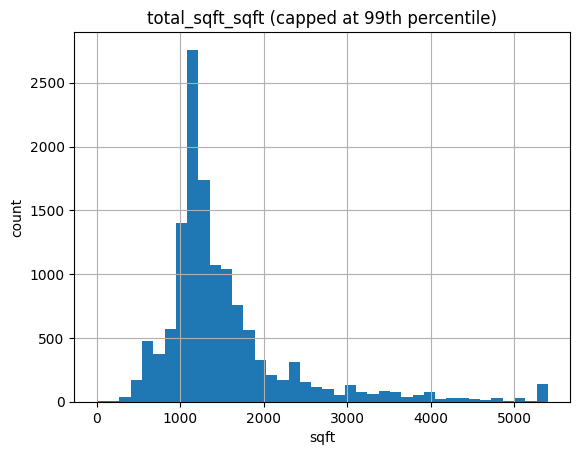

In [14]:
plt.figure()
fe_df['total_sqft_sqft'].clip(upper=fe_df['total_sqft_sqft'].quantile(0.99)).hist(bins=40)
plt.title('total_sqft_sqft (capped at 99th percentile)')
plt.xlabel('sqft')
plt.ylabel('count')
plt.show()

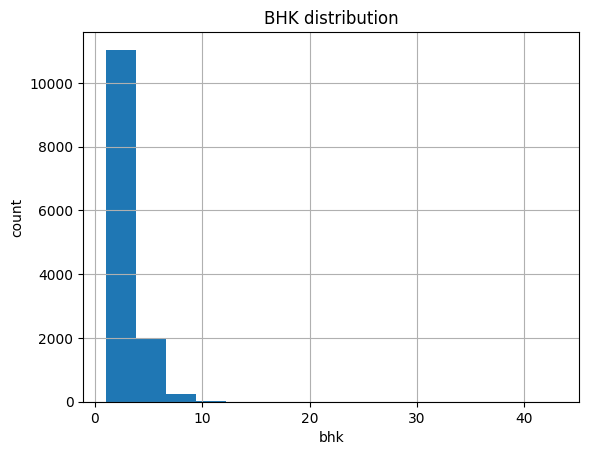

In [15]:
plt.figure()
fe_df['bhk'].hist(bins=15)
plt.title('BHK distribution')
plt.xlabel('bhk')
plt.ylabel('count')
plt.show()

### Define Column and split

In [16]:
cols_keep = ['area_type', 'availability', 'location', 'society',
             'total_sqft_sqft', 'bhk', 'bath', 'balcony', 'price']
data = fe_df[cols_keep].copy()

x = data.drop(columns=['price'])
y = data['price']


In [17]:
x.shape

(13320, 8)

In [18]:
num_cols = ['total_sqft_sqft', 'bhk', 'bath', 'balcony']
cat_cols = ['area_type', 'availability', 'location', 'society']

In [19]:
from sklearn.model_selection import train_test_split


x_train_raw, x_test_raw, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42
)

print("Shapes -> X_train, X_test:", x_train_raw.shape, x_test_raw.shape)
print("\nMissing in TRAIN:")
print(x_train_raw.isna().sum()[x_train_raw.isna().sum() > 0])
print("\nMissing in TEST:")
print(x_test_raw.isna().sum()[x_test_raw.isna().sum() > 0])

Shapes -> X_train, X_test: (10656, 8) (2664, 8)

Missing in TRAIN:
location       1
society     4387
bhk           14
bath          65
balcony      499
dtype: int64

Missing in TEST:
society    1115
bhk           2
bath          8
balcony     110
dtype: int64


### Variant A — Mean (numeric) + Most Frequent (categorical) with Linear Regression

In [20]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score

before_stats = x_train_raw[num_cols].agg(['mean', 'median', 'std']).T

num_imputer_mean = SimpleImputer(strategy='mean')
num_imputed_train = pd.DataFrame(
    num_imputer_mean.fit_transform(x_train_raw[num_cols]),
    columns=num_cols,
    index=x_train_raw.index
)
after_stats = num_imputed_train.agg(['mean', 'median', 'std']).T

stats_compare_mean = before_stats.join(
    after_stats,
    lsuffix='_before',
    rsuffix='_after'
).round(3)

print("=== Key stats (TRAIN) — Mean imputation ===")
display(stats_compare_mean)


=== Key stats (TRAIN) — Mean imputation ===


,mean_before,median_before,std_before,mean_after,median_after,std_after
total_sqft_sqft,1811.284,1280.0,13124.657,1811.284,1280.0,13124.657
bhk,2.809,3.0,1.251,2.809,3.0,1.250
bath,2.696,2.0,1.303,2.696,2.0,1.299
balcony,1.588,2.0,0.815,1.588,2.0,0.796


In [22]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_mean = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), num_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    remainder='drop'
)

pipe_mean = Pipeline(steps=[
    ('preprocess', preprocessor_mean),
    ('model', LinearRegression())
])

In [23]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse = -cross_val_score(pipe_mean, x_train_raw, y_train, cv=cv,
                           scoring='neg_root_mean_squared_error').mean()
cv_mae  = -cross_val_score(pipe_mean, x_train_raw, y_train, cv=cv,
                           scoring='neg_mean_absolute_error').mean()

In [24]:
pipe_mean.fit(x_train_raw, y_train)
y_pred = pipe_mean.predict(x_test_raw)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae  = mean_absolute_error(y_test, y_pred)
test_r2   = r2_score(y_test, y_pred)

print("\n=== Modeling performance — Mean imputation (LinearRegression) ===")
print(f"CV RMSE:  {cv_rmse:.3f}")
print(f"CV MAE:   {cv_mae:.3f}")
print(f"TEST RMSE:{test_rmse:.3f}")
print(f"TEST MAE: {test_mae:.3f}")
print(f"TEST R^2: {test_r2:.3f}")


=== Modeling performance — Mean imputation (LinearRegression) ===
CV RMSE:  129.507
CV MAE:   54.414
TEST RMSE:117.954
TEST MAE: 53.386
TEST R^2: 0.347


### Variant B: Median (numeric) + Most Frequent (categorical)

In [25]:
from IPython.display import display

before_stats = x_train_raw[num_cols].agg(['mean', 'median', 'std']).T

num_imputer_median = SimpleImputer(strategy='median')
num_imputed_train = pd.DataFrame(
    num_imputer_median.fit_transform(x_train_raw[num_cols]),
    columns=num_cols,
    index=x_train_raw.index
)
after_stats = num_imputed_train.agg(['mean', 'median', 'std']).T

stats_compare_median = before_stats.join(
    after_stats,
    lsuffix='_before',
    rsuffix='_after'
).round(3)

print("=== Key stats (TRAIN) — Median imputation ===")
display(stats_compare_median)

=== Key stats (TRAIN) — Median imputation ===


,mean_before,median_before,std_before,mean_after,median_after,std_after
total_sqft_sqft,1811.284,1280.0,13124.657,1811.284,1280.0,13124.657
bhk,2.809,3.0,1.251,2.809,3.0,1.250
bath,2.696,2.0,1.303,2.692,2.0,1.300
balcony,1.588,2.0,0.815,1.607,2.0,0.800


In [26]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_median = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    remainder='drop'
)

pipe_median = Pipeline(steps=[
    ('preprocess', preprocessor_median),
    ('model', LinearRegression())
])


In [27]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse = -cross_val_score(pipe_median, x_train_raw, y_train, cv=cv,
                           scoring='neg_root_mean_squared_error').mean()
cv_mae  = -cross_val_score(pipe_median, x_train_raw, y_train, cv=cv,
                           scoring='neg_mean_absolute_error').mean()

pipe_median.fit(x_train_raw, y_train)
y_pred = pipe_median.predict(x_test_raw)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae  = mean_absolute_error(y_test, y_pred)
test_r2   = r2_score(y_test, y_pred)

print("\n=== Modeling performance — Median imputation (LinearRegression) ===")
print(f"CV RMSE:  {cv_rmse:.3f}")
print(f"CV MAE:   {cv_mae:.3f}")
print(f"TEST RMSE:{test_rmse:.3f}")
print(f"TEST MAE: {test_mae:.3f}")
print(f"TEST R^2: {test_r2:.3f}")


=== Modeling performance — Median imputation (LinearRegression) ===
CV RMSE:  128.985
CV MAE:   54.389
TEST RMSE:117.926
TEST MAE: 53.429
TEST R^2: 0.347


#### Median vs Mean: Median is slightly better (CV RMSE 128.985 vs 129.507; Test RMSE 117.926 vs 117.954; MAE and R² ~same).

#### For the write-up, you can say: “Median imputation marginally improved generalization; differences are small because missingness is modest for numeric fields.”

## grouped forward fill and grouped backward fill

### Variant C: Grouped Forward Fill

In [29]:
def apply_group_ffill(df, group='location', order_cols=['bhk','total_sqft_sqft'], cols_to_fill=['bhk','bath','balcony','society']):
    d = df.copy()
    d = d.sort_values([group] + order_cols)
    for col in cols_to_fill:
        d[col] = d.groupby(group)[col].ffill()
    return d

def compute_group_stats(df, group='location', num_cols=None):
    num_cols = num_cols or []
    num_medians = df.groupby(group)[num_cols].median()
    # mode for 'society'
    soc_mode = df.groupby(group)['society'].agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
    return num_medians, soc_mode

train_ff = apply_group_ffill(x_train_raw)
train_ff

,area_type,availability,location,society,total_sqft_sqft,bhk,bath,balcony
2557,Built-up Area,Ready To Move,Anekal,NaN,351.0,1.0,1.0,1.0
8385,Super built-up Area,Ready To Move,Banaswadi,Krntsee,527.0,1.0,1.0,0.0
7638,Super built-up Area,Ready To Move,Basavangudi,NaN,670.0,1.0,1.0,1.0
2486,Super built-up Area,19-Dec,Bhoganhalli,Rosha I,296.0,1.0,1.0,0.0
2764,Super built-up Area,Ready To Move,Devarabeesana Halli,NaN,1100.0,2.0,2.0,1.0
...,...,...,...,...,...,...,...,...
9683,Plot Area,18-Apr,tc.palya,NaN,1400.0,3.0,2.0,1.0
11013,Super built-up Area,Ready To Move,vinayakanagar,NaN,1200.0,7.0,5.0,2.0
3483,Plot Area,Ready To Move,"white field,kadugodi",NaN,2100.0,6.0,6.0,NaN
4586,Super built-up Area,20-Dec,whitefiled,NaN,935.0,2.0,2.0,1.0


In [30]:
num_medians_train, soc_mode_train = compute_group_stats(train_ff, num_cols=['bhk','bath','balcony'])

for col in ['bhk','bath','balcony']:
    train_ff[col] = train_ff[col].fillna(train_ff['location'].map(num_medians_train[col]))
    train_ff[col] = train_ff[col].fillna(train_ff[col].median())
train_ff['society'] = train_ff['society'].fillna(train_ff['location'].map(soc_mode_train))
train_ff['society'] = train_ff['society'].fillna('Unknown')

test_ff = apply_group_ffill(x_test_raw)
for col in ['bhk','bath','balcony']:
    test_ff[col] = test_ff[col].fillna(test_ff['location'].map(num_medians_train[col]))
    test_ff[col] = test_ff[col].fillna(train_ff[col].median())
test_ff['society'] = test_ff['society'].fillna(test_ff['location'].map(soc_mode_train))
test_ff['society'] = test_ff['society'].fillna('Unknown')

print("Remaining NaNs in TRAIN:", train_ff.isna().sum().sum())
print("Remaining NaNs in TEST:", test_ff.isna().sum().sum())

Remaining NaNs in TRAIN: 1
Remaining NaNs in TEST: 0


In [31]:
before_stats = x_train_raw[num_cols].agg(['mean','median','std']).T
after_stats  = train_ff[num_cols].agg(['mean','median','std']).T
stats_compare_ffill = before_stats.join(after_stats, lsuffix='_before', rsuffix='_after').round(3)
print("=== Key stats (TRAIN) — Grouped forward fill ===")
display(stats_compare_ffill)

=== Key stats (TRAIN) — Grouped forward fill ===


,mean_before,median_before,std_before,mean_after,median_after,std_after
total_sqft_sqft,1811.284,1280.0,13124.657,1811.284,1280.0,13124.657
bhk,2.809,3.0,1.251,2.813,3.0,1.259
bath,2.696,2.0,1.303,2.702,2.0,1.308
balcony,1.588,2.0,0.815,1.603,2.0,0.819


In [33]:
pre_ff = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='drop')

pipe_ff = Pipeline([
    ('preprocess', pre_ff),
    ('model', LinearRegression())
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse = -cross_val_score(pipe_ff, train_ff, y_train, cv=cv, scoring='neg_root_mean_squared_error').mean()
cv_mae  = -cross_val_score(pipe_ff, train_ff, y_train, cv=cv, scoring='neg_mean_absolute_error').mean()

pipe_ff.fit(train_ff, y_train)
y_pred = pipe_ff.predict(test_ff)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae  = mean_absolute_error(y_test, y_pred)
test_r2   = r2_score(y_test, y_pred)

print("\n=== Modeling performance — Grouped Forward Fill (LinearRegression) ===")
print(f"CV RMSE:  {cv_rmse:.3f}")
print(f"CV MAE:   {cv_mae:.3f}")
print(f"TEST RMSE:{test_rmse:.3f}")
print(f"TEST MAE: {test_mae:.3f}")
print(f"TEST R^2: {test_r2:.3f}")


=== Modeling performance — Grouped Forward Fill (LinearRegression) ===
CV RMSE:  154.455
CV MAE:   79.167
TEST RMSE:148.379
TEST MAE: 77.893
TEST R^2: -0.034


### Variant D: Grouped Backward Fill

In [34]:
def apply_group_bfill(df, group='location', order_cols=['bhk','total_sqft_sqft'], cols_to_fill=['bhk','bath','balcony','society']):
    d = df.copy()
    d = d.sort_values([group] + order_cols)
    for col in cols_to_fill:
        d[col] = d.groupby(group)[col].bfill()
    return d

train_bf = apply_group_bfill(x_train_raw)
train_bf

,area_type,availability,location,society,total_sqft_sqft,bhk,bath,balcony
2557,Built-up Area,Ready To Move,Anekal,NaN,351.0,1.0,1.0,1.0
8385,Super built-up Area,Ready To Move,Banaswadi,Krntsee,527.0,1.0,1.0,0.0
7638,Super built-up Area,Ready To Move,Basavangudi,NaN,670.0,1.0,1.0,1.0
2486,Super built-up Area,19-Dec,Bhoganhalli,Rosha I,296.0,1.0,1.0,0.0
2764,Super built-up Area,Ready To Move,Devarabeesana Halli,Sorisa,1100.0,2.0,2.0,1.0
...,...,...,...,...,...,...,...,...
9683,Plot Area,18-Apr,tc.palya,NaN,1400.0,3.0,2.0,1.0
11013,Super built-up Area,Ready To Move,vinayakanagar,NaN,1200.0,7.0,5.0,2.0
3483,Plot Area,Ready To Move,"white field,kadugodi",NaN,2100.0,6.0,6.0,NaN
4586,Super built-up Area,20-Dec,whitefiled,NaN,935.0,2.0,2.0,1.0


In [35]:
def compute_group_stats(df, group='location', num_cols=None):
    num_cols = num_cols or []
    num_medians = df.groupby(group)[num_cols].median()
    soc_mode = df.groupby(group)['society'].agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
    return num_medians, soc_mode

num_medians_train_bf, soc_mode_train_bf = compute_group_stats(train_bf, num_cols=['bhk','bath','balcony'])

for col in ['bhk','bath','balcony']:
    train_bf[col] = train_bf[col].fillna(train_bf['location'].map(num_medians_train_bf[col]))
    train_bf[col] = train_bf[col].fillna(train_bf[col].median())
train_bf['society'] = train_bf['society'].fillna(train_bf['location'].map(soc_mode_train_bf))
train_bf['society'] = train_bf['society'].fillna('Unknown')

train_bf['location'] = train_bf['location'].fillna('Unknown')

test_bf = apply_group_bfill(x_test_raw)
for col in ['bhk','bath','balcony']:
    test_bf[col] = test_bf[col].fillna(test_bf['location'].map(num_medians_train_bf[col]))
    test_bf[col] = test_bf[col].fillna(train_bf[col].median())
test_bf['society'] = test_bf['society'].fillna(test_bf['location'].map(soc_mode_train_bf))
test_bf['society'] = test_bf['society'].fillna('Unknown')
test_bf['location'] = test_bf['location'].fillna('Unknown')

print("Remaining NaNs in TRAIN (bfill):", train_bf.isna().sum().sum())
print("Remaining NaNs in TEST  (bfill):", test_bf.isna().sum().sum())

Remaining NaNs in TRAIN (bfill): 0
Remaining NaNs in TEST  (bfill): 0


In [36]:
before_stats = x_train_raw[num_cols].agg(['mean','median','std']).T
after_stats  = train_bf[num_cols].agg(['mean','median','std']).T
stats_compare_bfill = before_stats.join(after_stats, lsuffix='_before', rsuffix='_after').round(3)
print("=== Key stats (TRAIN) — Grouped backward fill ===")
display(stats_compare_bfill)

=== Key stats (TRAIN) — Grouped backward fill ===


,mean_before,median_before,std_before,mean_after,median_after,std_after
total_sqft_sqft,1811.284,1280.0,13124.657,1811.284,1280.0,13124.657
bhk,2.809,3.0,1.251,2.808,3.0,1.250
bath,2.696,2.0,1.303,2.700,2.0,1.304
balcony,1.588,2.0,0.815,1.600,2.0,0.817


In [37]:
pre_bf = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='drop')

pipe_bf = Pipeline([
    ('preprocess', pre_bf),
    ('model', LinearRegression())
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse = -cross_val_score(pipe_bf, train_bf, y_train, cv=cv, scoring='neg_root_mean_squared_error').mean()
cv_mae  = -cross_val_score(pipe_bf, train_bf, y_train, cv=cv, scoring='neg_mean_absolute_error').mean()

pipe_bf.fit(train_bf, y_train)
y_pred = pipe_bf.predict(test_bf)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae  = mean_absolute_error(y_test, y_pred)
test_r2   = r2_score(y_test, y_pred)

print("\n=== Modeling performance — Grouped Backward Fill (LinearRegression) ===")
print(f"CV RMSE:  {cv_rmse:.3f}")
print(f"CV MAE:   {cv_mae:.3f}")
print(f"TEST RMSE:{test_rmse:.3f}")
print(f"TEST MAE: {test_mae:.3f}")
print(f"TEST R^2: {test_r2:.3f}")


=== Modeling performance — Grouped Backward Fill (LinearRegression) ===
CV RMSE:  154.454
CV MAE:   79.260
TEST RMSE:148.259
TEST MAE: 77.631
TEST R^2: -0.032


In [39]:
# ---------- helpers for grouped fills ----------
def apply_group_fill(df, method='ffill', group='location',
                     order_cols=['bhk','total_sqft_sqft'],
                     cols_to_fill=['bhk','bath','balcony','society']):
    d = df.copy()
    d = d.sort_values([group] + order_cols)
    for col in cols_to_fill:
        if method == 'ffill':
            d[col] = d.groupby(group)[col].ffill()
        else:
            d[col] = d.groupby(group)[col].bfill()
    return d

def compute_group_stats(df, group='location', num_cols=None):
    num_cols = num_cols or []
    num_medians = df.groupby(group)[num_cols].median()
    soc_mode = df.groupby(group)['society'].agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
    return num_medians, soc_mode

def evaluate_lr(Xtr, Xte, ytr, yte, preprocessor):
    pipe = Pipeline([('preprocess', preprocessor),
                     ('model', LinearRegression())])
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_rmse = -cross_val_score(pipe, Xtr, ytr, cv=cv, scoring='neg_root_mean_squared_error').mean()
    cv_mae  = -cross_val_score(pipe, Xtr, ytr, cv=cv, scoring='neg_mean_absolute_error').mean()
    pipe.fit(Xtr, ytr)
    ypred = pipe.predict(Xte)
    return {
        'CV_RMSE': cv_rmse,
        'CV_MAE':  cv_mae,
        'TEST_RMSE': np.sqrt(mean_squared_error(yte, ypred)),
        'TEST_MAE':  mean_absolute_error(yte, ypred),
        'TEST_R2':   r2_score(yte, ypred),
    }

results = {}

# ---- Mean ----
cat_tf = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                   ('onehot', OneHotEncoder(handle_unknown='ignore'))])
pre_mean = ColumnTransformer([
    ('num', SimpleImputer(strategy='mean'), num_cols),
    ('cat', cat_tf, cat_cols)
], remainder='drop')
results['Mean'] = evaluate_lr(x_train_raw, x_test_raw, y_train, y_test, pre_mean)

# ---- Median ----
pre_median = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', cat_tf, cat_cols)
], remainder='drop')
results['Median'] = evaluate_lr(x_train_raw, x_test_raw, y_train, y_test, pre_median)

# ---- Grouped FFill (+ fallbacks) ----
train_ff = apply_group_fill(x_train_raw, method='ffill')
num_med_ff, soc_mode_ff = compute_group_stats(train_ff, num_cols=['bhk','bath','balcony'])
for col in ['bhk','bath','balcony']:
    train_ff[col] = train_ff[col].fillna(train_ff['location'].map(num_med_ff[col]))
    train_ff[col] = train_ff[col].fillna(train_ff[col].median())
train_ff['society'] = train_ff['society'].fillna(train_ff['location'].map(soc_mode_ff)).fillna('Unknown')
train_ff['location'] = train_ff['location'].fillna('Unknown')

test_ff = apply_group_fill(x_test_raw, method='ffill')
for col in ['bhk','bath','balcony']:
    test_ff[col] = test_ff[col].fillna(test_ff['location'].map(num_med_ff[col]))
    test_ff[col] = test_ff[col].fillna(train_ff[col].median())
test_ff['society'] = test_ff['society'].fillna(test_ff['location'].map(soc_mode_ff)).fillna('Unknown')
test_ff['location'] = test_ff['location'].fillna('Unknown')

pre_ff = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='drop')
results['Grouped_FFill'] = evaluate_lr(train_ff, test_ff, y_train, y_test, pre_ff)

# ---- Grouped BFill (+ fallbacks) ----
train_bf = apply_group_fill(x_train_raw, method='bfill')
num_med_bf, soc_mode_bf = compute_group_stats(train_bf, num_cols=['bhk','bath','balcony'])
for col in ['bhk','bath','balcony']:
    train_bf[col] = train_bf[col].fillna(train_bf['location'].map(num_med_bf[col]))
    train_bf[col] = train_bf[col].fillna(train_bf[col].median())
train_bf['society'] = train_bf['society'].fillna(train_bf['location'].map(soc_mode_bf)).fillna('Unknown')
train_bf['location'] = train_bf['location'].fillna('Unknown')

test_bf = apply_group_fill(x_test_raw, method='bfill')
for col in ['bhk','bath','balcony']:
    test_bf[col] = test_bf[col].fillna(test_bf['location'].map(num_med_bf[col]))
    test_bf[col] = test_bf[col].fillna(train_bf[col].median())
test_bf['society'] = test_bf['society'].fillna(test_bf['location'].map(soc_mode_bf)).fillna('Unknown')
test_bf['location'] = test_bf['location'].fillna('Unknown')

pre_bf = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='drop')
results['Grouped_BFill'] = evaluate_lr(train_bf, test_bf, y_train, y_test, pre_bf)

# ---- Assemble table ----
comparison = (pd.DataFrame(results)
              .T[['CV_RMSE','CV_MAE','TEST_RMSE','TEST_MAE','TEST_R2']]
              .sort_values('TEST_RMSE'))
comparison.round(3)

,CV_RMSE,CV_MAE,TEST_RMSE,TEST_MAE,TEST_R2
Median,128.985,54.389,117.926,53.429,0.347
Mean,129.507,54.414,117.954,53.386,0.347
Grouped_BFill,154.454,79.260,148.259,77.631,-0.032
Grouped_FFill,154.452,79.161,148.379,77.893,-0.034


### Final baseline (Median imputation + LinearRegression) on 5 features

In [40]:
feat_cols = ['location', 'bhk', 'total_sqft_sqft', 'bath', 'balcony']
num5 = ['bhk', 'total_sqft_sqft', 'bath', 'balcony']
cat5 = ['location']

Xtr5 = x_train_raw[feat_cols].copy()
Xte5 = x_test_raw[feat_cols].copy()

print("Missing in TRAIN (selected 5):")
print(Xtr5.isna().sum()[Xtr5.isna().sum() > 0])
print("\nMissing in TEST (selected 5):")
print(Xte5.isna().sum()[Xte5.isna().sum() > 0])

Missing in TRAIN (selected 5):
location      1
bhk          14
bath         65
balcony     499
dtype: int64

Missing in TEST (selected 5):
bhk          2
bath         8
balcony    110
dtype: int64


In [41]:
cat_tf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preproc_median_5 = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num5),
        ('cat', cat_tf, cat5)
    ],
    remainder='drop'
)

final_lr_pipe = Pipeline(steps=[
    ('preprocess', preproc_median_5),
    ('model', LinearRegression())
])

# CV on TRAIN
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse = -cross_val_score(final_lr_pipe, Xtr5, y_train, cv=cv,
                           scoring='neg_root_mean_squared_error').mean()
cv_mae  = -cross_val_score(final_lr_pipe, Xtr5, y_train, cv=cv,
                           scoring='neg_mean_absolute_error').mean()

# Fit + TEST metrics
final_lr_pipe.fit(Xtr5, y_train)
y_pred5 = final_lr_pipe.predict(Xte5)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred5))
test_mae  = mean_absolute_error(y_test, y_pred5)
test_r2   = r2_score(y_test, y_pred5)

print("\n=== Final Baseline (5 features, Median imputation, LinearRegression) ===")
print(f"CV RMSE:  {cv_rmse:.3f}")
print(f"CV MAE:   {cv_mae:.3f}")
print(f"TEST RMSE:{test_rmse:.3f}")
print(f"TEST MAE: {test_mae:.3f}")
print(f"TEST R^2: {test_r2:.3f}")


=== Final Baseline (5 features, Median imputation, LinearRegression) ===
CV RMSE:  134.843
CV MAE:   55.322
TEST RMSE:124.881
TEST MAE: 54.965
TEST R^2: 0.267


In [42]:
Xtr5

,location,bhk,total_sqft_sqft,bath,balcony
3411,Lingadheeranahalli,3.0,1530.0,2.0,2.0
9142,Cooke Town,2.0,1310.0,2.0,2.0
1971,Raja Rajeshwari Nagar,3.0,1530.0,3.0,2.0
2608,Banashankari,4.0,2400.0,3.0,2.0
9635,Kanakapura,2.0,1017.0,2.0,1.0
...,...,...,...,...,...
11964,Varanasi,5.0,1200.0,4.0,1.0
5191,Kogilu,3.0,1559.0,3.0,2.0
5390,Garudachar Palya,2.0,1060.0,2.0,1.0
860,Raja Rajeshwari Nagar,6.0,1200.0,4.0,2.0


In [43]:
Xte5

,location,bhk,total_sqft_sqft,bath,balcony
8077,Banjara Layout,2.0,1050.0,2.0,1.0
1602,Rajiv Nagar,3.0,1690.0,3.0,1.0
10498,Hebbal,2.0,1100.0,2.0,1.0
3297,Munnekollal,6.0,1200.0,4.0,2.0
8893,Choodasandra,4.0,2429.0,3.0,1.0
...,...,...,...,...,...
1082,Ananth Nagar,1.0,500.0,1.0,1.0
1671,Herohalli,5.0,1800.0,6.0,0.0
4325,AECS Layout,3.0,1800.0,3.0,3.0
7375,Vinayaka Nagar,2.0,1200.0,2.0,2.0


In [44]:
# 1) Baseline "before" stats (TRAIN numeric only)
before = x_train_raw[num_cols].agg(['mean','median','std']).T

# --- helper: grouped fill with fallbacks, consistent with earlier cells ---
def apply_group_fill(df, method='ffill', group='location',
                     order_cols=['bhk','total_sqft_sqft'],
                     cols_to_fill=['bhk','bath','balcony','society']):
    d = df.copy()
    d = d.sort_values([group] + order_cols)
    for col in cols_to_fill:
        d[col] = d.groupby(group)[col].ffill() if method=='ffill' else d.groupby(group)[col].bfill()
    return d

def compute_group_stats(df, group='location', num_cols=None):
    num_cols = num_cols or []
    num_meds = df.groupby(group)[num_cols].median()
    soc_mode = df.groupby(group)['society'].agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
    return num_meds, soc_mode

def train_after_stats_mean():
    imputer = SimpleImputer(strategy='mean')
    tmp = pd.DataFrame(imputer.fit_transform(x_train_raw[num_cols]),
                       columns=num_cols, index=x_train_raw.index)
    return tmp.agg(['mean','median','std']).T

def train_after_stats_median():
    imputer = SimpleImputer(strategy='median')
    tmp = pd.DataFrame(imputer.fit_transform(x_train_raw[num_cols]),
                       columns=num_cols, index=x_train_raw.index)
    return tmp.agg(['mean','median','std']).T

def train_after_stats_group(method='ffill'):
    t = apply_group_fill(x_train_raw, method=method)
    meds, smode = compute_group_stats(t, num_cols=['bhk','bath','balcony'])
    for col in ['bhk','bath','balcony']:
        t[col] = t[col].fillna(t['location'].map(meds[col]))
        t[col] = t[col].fillna(t[col].median())
    t['society'] = t['society'].fillna(t['location'].map(smode)).fillna('Unknown')
    return t[num_cols].agg(['mean','median','std']).T

# 2) Collect AFTER stats for each method
after_mean   = train_after_stats_mean()
after_median = train_after_stats_median()
after_ffill  = train_after_stats_group('ffill')
after_bfill  = train_after_stats_group('bfill')

# 3) Build a single table of deltas (after - before)
def deltas(after, label):
    out = after.join(before, lsuffix='_after', rsuffix='_before')
    out = pd.DataFrame({
        (label, 'mean_delta'):   (out['mean_after']   - out['mean_before']).round(3),
        (label, 'median_delta'): (out['median_after'] - out['median_before']).round(3),
        (label, 'std_delta'):    (out['std_after']    - out['std_before']).round(3),
    })
    return out

delta_tbl = pd.concat([
    deltas(after_mean,   'Mean'),
    deltas(after_median, 'Median'),
    deltas(after_ffill,  'Grouped_FFill'),
    deltas(after_bfill,  'Grouped_BFill'),
], axis=1)

# Make it pretty
delta_tbl = delta_tbl.reindex(index=num_cols)
delta_tbl

Mean                            Median               \
                mean_delta median_delta std_delta mean_delta median_delta   
total_sqft_sqft        0.0          0.0     0.000      0.000          0.0   
bhk                   -0.0          0.0    -0.001      0.000          0.0   
bath                   0.0          0.0    -0.004     -0.004          0.0   
balcony                0.0          0.0    -0.019      0.019          0.0   

                          Grouped_FFill                        Grouped_BFill  \
                std_delta    mean_delta median_delta std_delta    mean_delta   
total_sqft_sqft     0.000         0.000          0.0    -0.000         0.000   
bhk                -0.001         0.004          0.0     0.008        -0.000   
bath               -0.003         0.006          0.0     0.005         0.004   
balcony            -0.015         0.015          0.0     0.004         0.012   

                                        
                median_delta std_delta  
total_sqft_sqft          0.0    -0.000  
bhk                      0.0    -0.001  
bath                     0.0     0.001  
balcony                  0.0     0.002

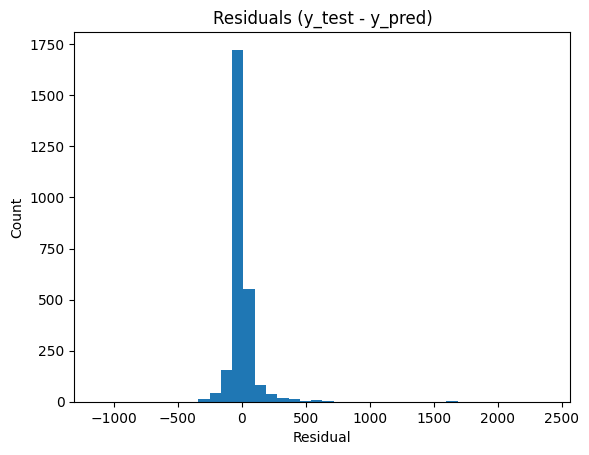

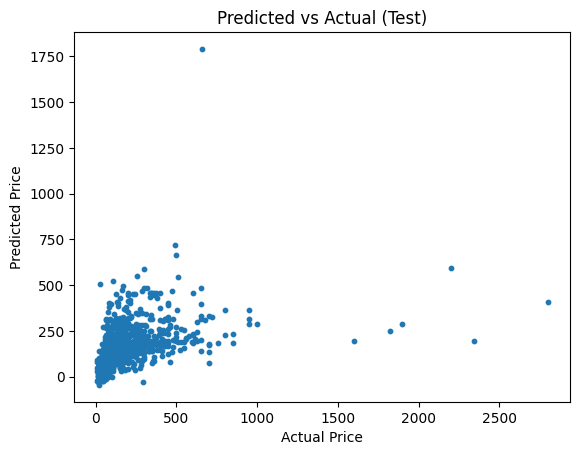

In [45]:
# Ensure predictions exist
y_pred5 = final_lr_pipe.predict(Xte5)

# Residuals
residuals = y_test - y_pred5

# 1) Residual histogram
plt.figure()
plt.hist(residuals, bins=40)
plt.title("Residuals (y_test - y_pred)")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

# 2) Predicted vs Actual scatter
plt.figure()
plt.scatter(y_test, y_pred5, s=10)
plt.title("Predicted vs Actual (Test)")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

In [46]:
pre = final_lr_pipe.named_steps['preprocess']
model = final_lr_pipe.named_steps['model']

feat_names = pre.get_feature_names_out()
coefs = model.coef_

coef_df = pd.DataFrame({
    "feature": feat_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

print("\nTop 15 features by absolute coefficient:")
print(coef_df.head(15).drop(columns="abs_coef").to_string(index=False))


Top 15 features by absolute coefficient:
                            feature       coef
         cat__location_Rajaji Nagar 314.019720
         cat__location_Malleshwaram 289.351378
      cat__location_Sadashiva Nagar 242.644405
               cat__location_Yemlur 242.519526
      cat__location_Cunningham Road 223.478378
         cat__location_Indira Nagar 150.825211
       cat__location_Dollars Colony 135.644032
          cat__location_Koramangala 123.972728
       cat__location_Defence Colony 123.267446
          cat__location_Frazer Town  96.880603
cat__location_Ramakrishnappa Layout  92.570416
    cat__location_Sathya Sai Layout  84.725557
cat__location_Raja Rajeshwari Nagar -82.936965
          cat__location_Ashok Nagar  81.500004
        cat__location_Vasanth nagar  80.482460


In [47]:
def predict_price(location, bhk, total_sqft_sqft, bath, balcony):
    X_new = pd.DataFrame([{
        'location': location,
        'bhk': float(bhk),
        'total_sqft_sqft': float(total_sqft_sqft),
        'bath': float(bath),
        'balcony': float(balcony),
    }])
    # One-hot for unknown locations is handled by the pipeline (ignored)
    pred_lakh = float(final_lr_pipe.predict(X_new)[0])
    pred_inr  = pred_lakh * 1e5
    pred_cr   = pred_lakh / 100.0
    return pred_lakh, pred_inr, pred_cr

In [48]:
example_inputs = {
    "location": "Indira Nagar",
    "bhk": 3,
    "total_sqft_sqft": 1200,
    "bath": 2,
    "balcony": 2
}

pred_lakh, pred_inr, pred_cr = predict_price(**example_inputs)
print("Input:", example_inputs)
print(f"Predicted Price: {pred_lakh:,.2f} Lakh  |  ₹{pred_inr:,.0f}  |  ₹{pred_cr:,.2f} Cr")

# --- Overall test-set performance (same as your baseline model) ---
y_pred = final_lr_pipe.predict(Xte5)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("\n=== Overall Test Performance ===")
print(f"RMSE: {rmse:.3f}  (Lakh)")
print(f"MAE:  {mae:.3f}  (Lakh)")
print(f"R²:   {r2:.3f}")

Input: {'location': 'Indira Nagar', 'bhk': 3, 'total_sqft_sqft': 1200, 'bath': 2, 'balcony': 2}
Predicted Price: 240.39 Lakh  |  ₹24,039,436  |  ₹2.40 Cr

=== Overall Test Performance ===
RMSE: 124.881  (Lakh)
MAE:  54.965  (Lakh)
R²:   0.267
